In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [113]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

from functions import conversion, rotate_data

def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def fit( t, xdata, ydata,name, p0: list = [180, 2000, 0.017, -1.5, 630], xlabel=False, cutoff: int = 0,cutoffend:  int = -1, zero_pos: tuple[float | int] | None = None,
        h1: list[ufloat] | None = None, h2: list[ufloat] | None = None, plot: bool = False):

    x, y, x0 = rotate_data(xdata, ydata, zero_pos=zero_pos)
    
    popt, pcov = curve_fit(theta, t[cutoff:cutoffend], x[cutoff:cutoffend], p0=p0) 

    if x0 != None:
        o = ufloat(popt[4], pcov[4,4]**0.5) - x0
        result = np.append(unp.uarray(popt, np.sqrt(np.diag(pcov))), o)
    else:
        result = unp.uarray(popt, np.sqrt(np.diag(pcov)))

    if plot:
        plt.figure(figsize=(9,2))
        plt.subplot(121)

        err = 1*conv.n
        
        plt.errorbar(t, (x - popt[4])*conv.n, yerr= err, fmt='k.', ecolor='grey' , capsize=1, linewidth=0.6, ms=0.8, label='x-data', zorder=1)
        plt.plot(t[cutoff:cutoffend], (theta(t[cutoff:cutoffend], *popt) - popt[4])*conv.n, 'r',  zorder=3)
        plt.ylabel('x [cm]')
        if xlabel == True:
            plt.xlabel('t [s]')
            plt.legend()
        plt.grid()

        #we need chi2 
        ndf = len(x[cutoff:cutoffend])-5
        Chi2= np.sum( (  (x[cutoff:cutoffend]*conv.n- theta(t[cutoff:cutoffend], *popt)*conv.n) /(err) )**2) /ndf

        #Chi2= np.sum( (  (x[cutoff:cutoffend]- theta(t[cutoff:cutoffend], *popt)) / x[cutoff:cutoffend])**2) /ndf
        #Chi2= np.sum(   (x[cutoff:cutoffend]*conv.n- theta(t[cutoff:cutoffend], *popt)*conv.n) /(x[cutoff:cutoffend]*conv.n )**2) /ndf

        chi2 = round(Chi2,2)

        
        plt.title(f'{name}; $\chi^2/dof$={chi2}')

        plt.subplot(122)

        plt.errorbar(t, y*conv.n, yerr= err  ,  fmt='k.',  ecolor='grey', capsize=0.5, linewidth=0.6, ms=0.8, label='y-data')
        plt.ylabel('y [cm]')
        if xlabel == True:
            plt.xlabel('t [s]')
            plt.legend()
        plt.grid()


        plt.tight_layout()
        plt.savefig(f'{name}.png')
        plt.savefig(f'{name}.pdf')
    return result


<>:61: SyntaxWarning: invalid escape sequence '\c'
<>:61: SyntaxWarning: invalid escape sequence '\c'
C:\Users\janbu\AppData\Local\Temp\ipykernel_8840\1467973105.py:61: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'{name}; $\chi^2/dof$={chi2}')


C:\Users\janbu\AppData\Local\Temp\ipykernel_8840\4079096467.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


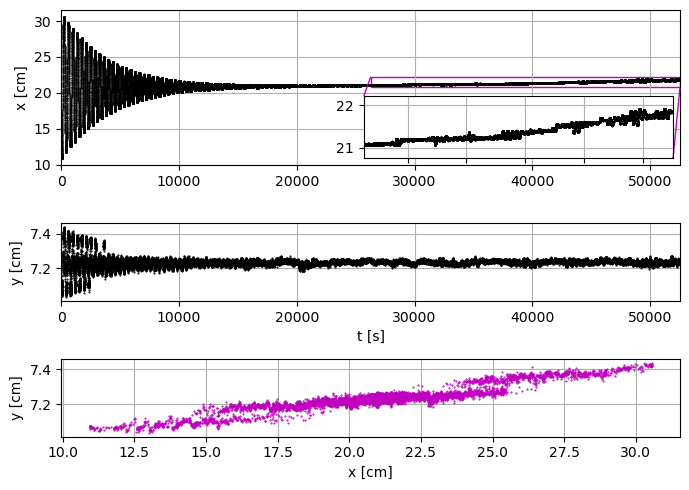

In [114]:
# load data
night = np.loadtxt('m5/m5_p0_nacht.txt', skiprows=2, unpack=True)

plt.figure(figsize=(7,5))

t = night[0,:]
x = night[1,:]*0.160
y = night[2,:]*0.160


gs = plt.GridSpec(3, 1, height_ratios=[1, 0.5, 0.5])
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
ax3 = plt.subplot(gs[2])
# --- First subplot ---
ax1.plot(t, x, 'k.', ms=1)
ax1.set_xlim(0, 52554)
ax1.grid()
ax1.set_ylabel('x [cm]')

# 🔍 inset zoom (second half)
axins = inset_axes(ax1, width="50%", height="40%", loc='lower right')

half = len(t)//2
axins.plot(t[half:], x[half:], 'k.', ms=1)
axins.set_xlim(t[half], t[-1])
axins.set_ylim(min(x[half:]-0.3), max(x[half:]+0.3))

# remove ticks for clean look
#axins.set_xticks([])
#axins.set_yticks([])
axins.tick_params(axis='x', labelbottom=False)  # hide x numbers, keep ticks/grid
#axins.tick_params(axis='both', which='both', length=0)

# connect inset to main plot
#mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="m")
axins.grid()
# --- Second subplot ---
ax2.plot(t, y, 'k.', ms=1)
ax2.grid()
ax2.set_xlim(0, 52554)
ax2.set_ylabel('y [cm]')
ax2.set_xlabel('t [s]')

# --- Third subplot ---
ax3.plot(x, y, 'm.', ms=1)
ax3.grid()
ax3.set_ylabel('y [cm]')
ax3.set_xlabel('x [cm]')

plt.tight_layout()
plt.savefig('night_zoom.png')
plt.savefig('night_zoom.pdf')
plt.show()

C:\Users\janbu\AppData\Local\Temp\ipykernel_8840\3509317205.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


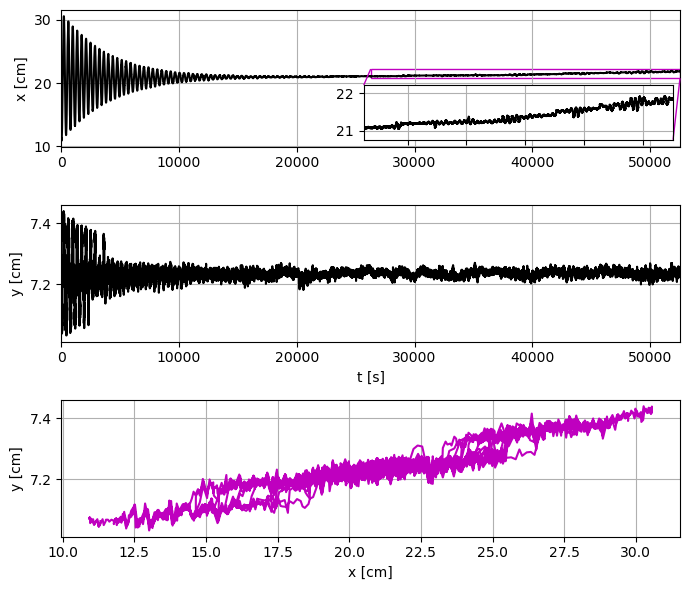

In [56]:
# load data
night = np.loadtxt('m5/m5_p0_nacht.txt', skiprows=2, unpack=True)

plt.figure(figsize=(7,6))

t = night[0,:]
x = night[1,:]*0.160
y = night[2,:]*0.160

# --- First subplot ---
ax1 = plt.subplot(311)
ax1.plot(t, x, 'k')
ax1.set_xlim(0, 52554)
ax1.grid()
ax1.set_ylabel('x [cm]')

# 🔍 inset zoom (second half)
axins = inset_axes(ax1, width="50%", height="40%", loc='lower right')

half = len(t)//2
axins.plot(t[half:], x[half:], 'k')
axins.set_xlim(t[half], t[-1])
axins.set_ylim(min(x[half:]-0.3), max(x[half:]+0.3))

# remove ticks for clean look
#axins.set_xticks([])
#axins.set_yticks([])
axins.tick_params(axis='x', labelbottom=False)  # hide x numbers, keep ticks/grid
#axins.tick_params(axis='both', which='both', length=0)

# connect inset to main plot
#mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="m")
axins.grid()
# --- Second subplot ---
ax2 = plt.subplot(312)
ax2.plot(t, y, 'k')
ax2.grid()
ax2.set_xlim(0, 52554)
ax2.set_ylabel('y [cm]')
ax2.set_xlabel('t [s]')

# --- Third subplot ---
ax3 = plt.splot(313)
ax3.plot(x, y, 'm')
ax3.grid()
ax3.set_ylabel('y [cm]')
ax3.set_xlabel('x [cm]')

plt.tight_layout()
#plt.savefig('night_zoom.png')
#plt.savefig('night_zoom.pdf')
plt.show()

(3, 52554)


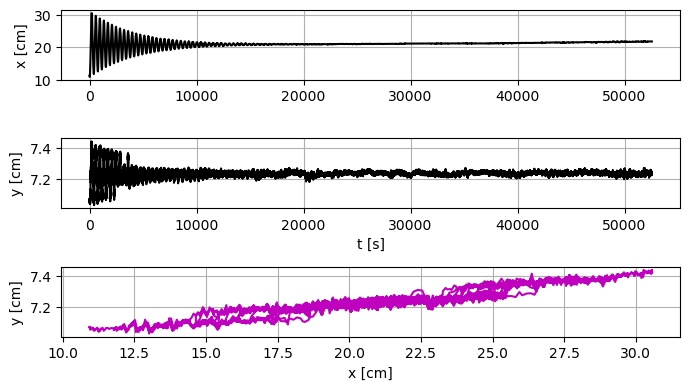

In [22]:
#night meas analysis
night = np.loadtxt('m5/m5_p0_nacht.txt', skiprows=2, unpack=True)
print(night.shape)
plt.figure(figsize=(7,4))
plt.subplot(311)
plt.plot(night[0,:],night[1,:]*0.160, 'k')
#plt.ylim(120*0.160,140*0.160)
plt.grid()
plt.ylabel('x [cm]')
plt.subplot(312)
plt.plot(night[0,:],night[2,:]*0.160, 'k')
plt.grid()
plt.ylabel('y [cm]')
plt.xlabel('t [s]')
plt.subplot(313)
plt.plot(night[1,:]*0.160,night[2,:]*0.160, 'm')
plt.grid()
plt.ylabel('y [cm]')
plt.xlabel('x [cm]')

plt.tight_layout()
#plt.savefig('night_raw.png')
#plt.savefig('night_raw.pdf')

In [107]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

def fit(t, xdata, ydata, p0: list = [180, 2000, 0.017, -1.5, 630], cutoff: int = 0):
    x, y = rotate_data(t, xdata, ydata)

    popt, pcov = curve_fit(theta, t[cutoff:], x[cutoff:], p0=p0)

    fig, (ax1, ax2) = plt.subplots(2, sharex=True)

    ax1.plot(t, x - popt[4], 'k.', ms=1)
    ax1.plot(t[cutoff:], theta(t[cutoff:], *popt) - popt[4], 'r')
    #ax1.set_xlabel('t')
    ax1.set_ylabel('x')

    ax2.errorbar(t, y, fmt='k.', capsize=1, linewidth=0.6, ms=0.8)
    ax2.set_xlabel('t')
    ax2.set_ylabel('y')

    #T = 2 * np.pi / ufloat(popt[2], pcov[2,2]**0.5)

    return unp.uarray(popt, np.sqrt(np.diag(pcov)))

In [108]:
def conversion(h1,h2):
    # known length of h, v in m
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    #conversion factor calc + uncertainty

    #calculation
    #h_diff = h2-h1
    #v_diff = v2-v1
    # pixel conversion factors
    #x_px = l_h * unp.cos(unp.arctan(h_diff[0]/h_diff[1])) # m / fake m
    #y_px = l_v * unp.cos(unp.arctan(v_diff[1]/v_diff[0])) # m / fake m
    #print(h_diff)
    #print(h_diff[1])
    #print(h_diff[0])

    #print(conversion(h1,h2,v1,v2))
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    alpha = unp.arctan( (h2[1]-h1[1])/(h2[0]-h1[0]) )
    H = (h2[1]-h1[1])/unp.sin(alpha)
    
    return l_h/H

In [109]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-199.5 ,-72.7 ], [5,5]) # coordinates in virt m 
h2 = unp.uarray([ 88.6, -74.69], [5,5])# virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))
conv = conversion(h1,h2)

0.160+/-0.004


In [115]:
# calculate G , incl uncertainties
def G_12(R, theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

    #I = m*l**2/2 #kg m^2, using MIT estimated formula
    l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
    #l=unp.uarray(0.12, 0.001)
    rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
    #I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    #delta_r = 0.0
    #ADJUST r1, r2, r3
    #r = unp.uarray( R  + delta_r, 0.003) #m  51.722+/-0.011 #meas with messschieber in the air, could be improved

        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= unp.arctan( ((h2 - h1)*0.5)*0.01 / 4.321) #0.01 go from cm to m
        
    #units kg m^2 /s^2  * m^2/kg^2/m
    G = (r)**2 * (l)/(8*M) * (2*np.pi/T)**2 * dtheta  #using MIT I that cancels, we could get a correction here

    #print('eq1:',h1,'eq2:',h2, 'in cm')
    
    return G

In [116]:
#get period T0
T =  2*np.pi/fit(*np.loadtxt('m7/m7_p0.txt', skiprows=2, unpack=True),'T', cutoff=500)[2]
print('period from zero measurement = ', T)

period from zero measurement =  377.328+/-0.016


G12 = (7.5+/-0.9)e-11
G01 = (6.3+/-0.7)e-11
G02 = (8.6+/-1.0)e-11
157.918+/-0.007
132.308+/-0.031
192.876+/-0.018


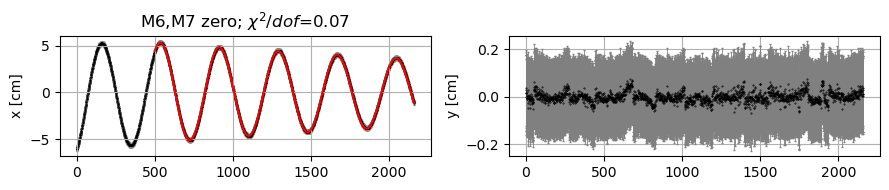

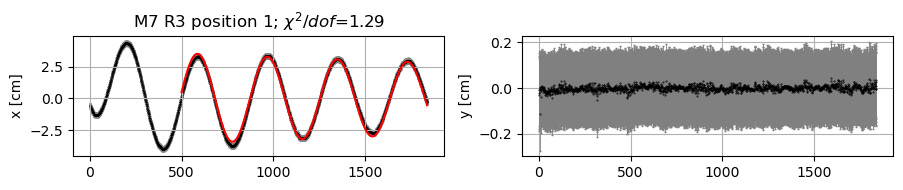

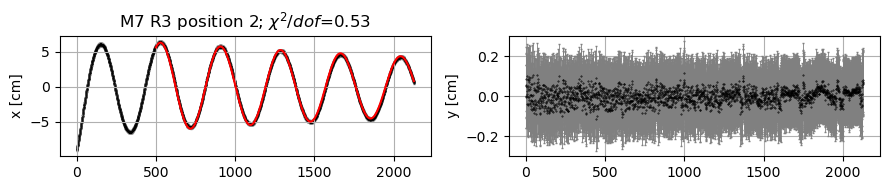

In [125]:
#T = ufloat(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
#theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
#theta2=unp.uarray(1249.6597283089984, 0)
theta0 = fit(*np.loadtxt('m7/m7_p0.txt', skiprows=2, unpack=True), 'M6,M7 zero', cutoff=500, plot=True)[4]
theta1 = fit(*np.loadtxt('m7/m7_p1_r3.txt', skiprows=2, unpack=True), 'M7 R3 position 1', cutoff=500, plot=True)[4]
theta2 = fit(*np.loadtxt('m7/m7_p2_r3.txt', skiprows=2, unpack=True), 'M7 R3 position 2', cutoff=500, plot=True)[4]

#REMEMBER TO ADJUST R:
R1 = 0.087
R2 = 0.068
R3 = 0.053

delta_r = 0.0
r = unp.uarray( R3  + delta_r, 0.003) 

conversion_factor =conversion(h1,h2)
print('G12 =',G_12(r, theta1, theta2, T, conversion_factor)) # *2 for G01,2 
print('G01 =',G_12(r, theta1, theta0, T, conversion_factor)*2)
print('G02 =',G_12(r, theta0, theta2, T, conversion_factor)*2)

print(theta0)
print(theta1)
print(theta2)

In [13]:
#weighted mean: 


x = np.array((6.8e-11,7.3e-11,6.3e-11))
m = np.mean(x)

err = np.array((0.6e-11,0.7e-11,0.6e-11))
w = 1/err**2 #weights

#diff errors weighted mean
err = np.sqrt(1/(np.sum(w)))
WM = np.sum(x*w)/np.sum(w)

#error on this mean
print('normal mean',m)
print('weighted mean',WM)
print('err=',np.sum(err)/np.sqrt(3))

normal mean 6.800000000000001e-11
weighted mean 6.751492537313433e-11
err= 2.094769605826029e-12


In [84]:
#all weighted means:
m5 =  6.6e-11
m5_err = 1.1e-11

m5_vac = 9.6e-11
m5_vac_err = 1.6e-11

m6 =  11.0e-11
m6_err = 0.9e-11

m5_r1 = 8.0e-11
m5_r1_err = 0.9e-11

m5_r2 = 6.7e-11
m5_r2_err = 0.7e-11

m5_r3 = 7.2e-11
m5_r3_err = 0.6e-11

m8_r4 = 6.75e-11
m8_r4_err = 0.6e-11

m9 = 6.4e-11
m9_err = 1.5e-11


print('important argument: 01,02 scatter due to systematic so if we average we kill the systematic! think about if uncert are affected by this syst')

important argument: 01,02 scatter due to systematic so if we average we kill the systematic! think about if uncert are affected by this syst


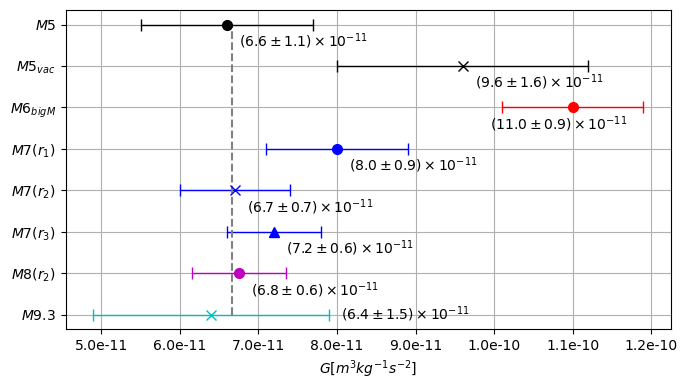

In [93]:
# plot for all results, incl errorbars
plt.figure(figsize=(7,4))
y_pos = [6,5,4,3,2,1,0,-1]

plt.errorbar(m5, 6, xerr=m5_err, fmt='ko', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5')

plt.errorbar(m5_vac, 5, xerr=m5_vac_err, fmt='kx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5_vac')

plt.errorbar(m6, 4, xerr=m6_err, fmt='ro', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m6')

#varying r
plt.errorbar(m5_r1, 3, xerr=m5_r1_err, fmt='bo', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r1')
plt.errorbar(m5_r2, 2, xerr=m5_r2_err, fmt='bx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r2')
plt.errorbar(m5_r3, 1, xerr=m5_r3_err, fmt='b^', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5 r3')

plt.errorbar(m8_r4, 0, xerr=m8_r4_err, fmt='mo', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m8 r4')

plt.errorbar(m9, -1, xerr=m9_err, fmt='cx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m8 r4')

plt.vlines(6.67e-11,-1,6, 'gray', label='literature', linestyle='dashed')
plt.xlabel('$G [m^3 kg^{-1} s^{-2}]$')
plt.yticks([])
from matplotlib.ticker import FormatStrFormatter
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1e'))
#plt.legend()

# Set y-axis labels instead of numbers
plt.yticks(y_pos, ['$M5$','$M5_{vac}$','$M6_{bigM}$','$M7(r_1)$','$M7(r_2)$','$M7(r_3)$', '$M8(r_2)$', '$M9.3$'])

plt.grid()

# ---- ADD VALUE LABELS ----
offset = 0.15e-11  # horizontal shift for text
off_down = 0.4
plt.text(m5 + offset, 6-off_down, r'$(6.6\pm1.1)\times10^{-11}$', va='center')
plt.text(m5_vac + offset, 5-off_down, r'$(9.6\pm1.6)\times10^{-11}$', va='center')
plt.text(m6 - 7*offset, 4-off_down, r'$(11.0\pm0.9)\times10^{-11}$', va='center')

plt.text(m5_r1 + offset, 3-off_down, r'$(8.0\pm0.9)\times10^{-11}$', va='center')
plt.text(m5_r2 + offset, 2-off_down, r'$(6.7\pm0.7)\times10^{-11}$', va='center')
plt.text(m5_r3 + offset, 1-off_down, r'$(7.2\pm0.6)\times10^{-11}$', va='center')

plt.text(m8_r4 + offset, 0-off_down, r'$(6.8\pm0.6)\times10^{-11}$', va='center')
plt.text(m9 + 11*offset, -1, r'$(6.4\pm1.5)\times10^{-11}$', va='center')
plt.tight_layout()
plt.savefig('results.png')
plt.savefig('results.pdf')